# Линейная регрессия с разными функциями потерь на синтетических данных

## Генерация аффинной зависимости

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
sample_size = 101

In [23]:
X = np.linspace(10, 11, sample_size)

In [48]:
w0_exact = 3.0
w1_exact = 2.0

In [25]:
Y = w0_exact + w1_exact * X

## Генерация и сохранение шумов

In [26]:
def random_contaminated_normal(loc, main_scale, outlier_scale, outlier_proba, size=None):
    if size is None:
        return np.random.normal(
            loc = loc,
            scale = main_scale if np.random.uniform() > outlier_proba else outlier_scale
        )
    else:
        return np.fromfunction(
            np.vectorize(lambda *x: random_contaminated_normal(loc, main_scale, outlier_scale, outlier_proba)),
            size
        )

normal white


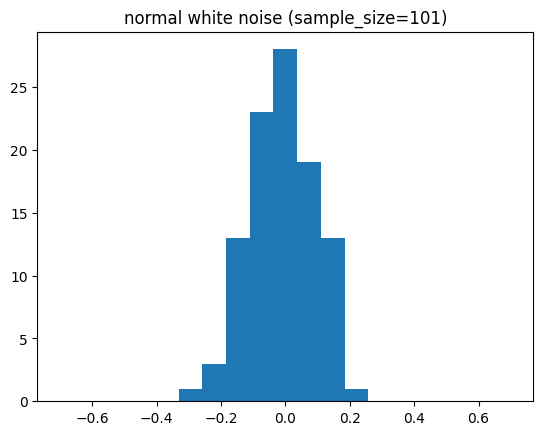

Laplace white


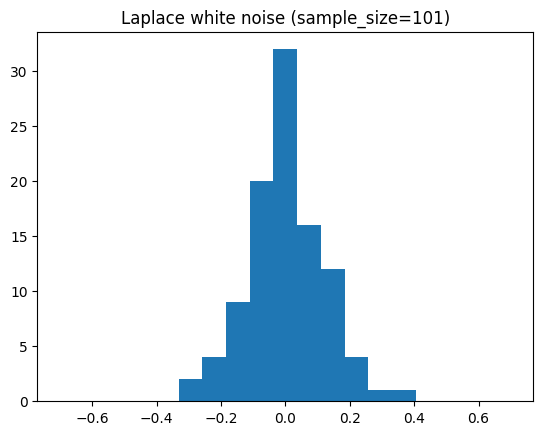

logistic white


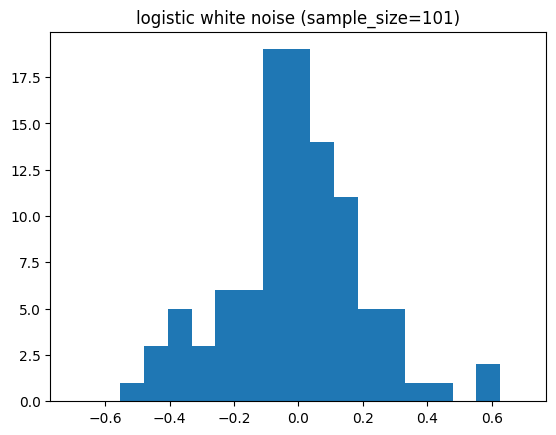

Cauchy white


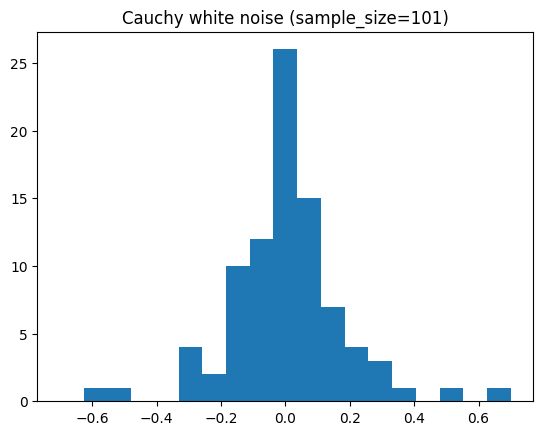

Student(2) white


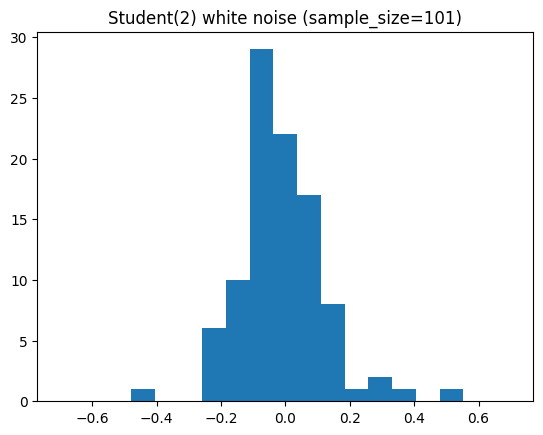

Student(3) white


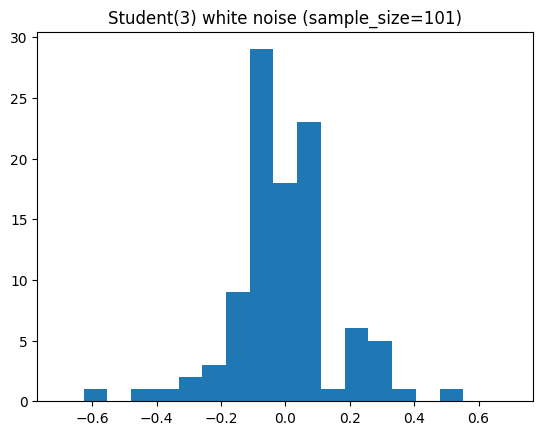

Student(4) white


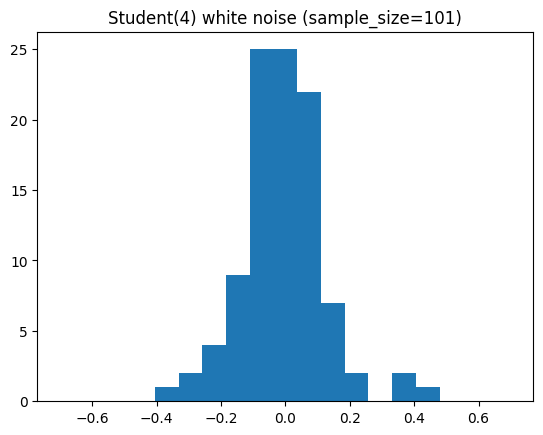

Tukey white


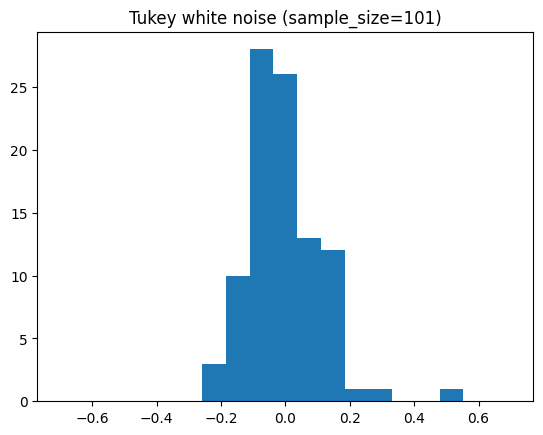

normal AR(1)


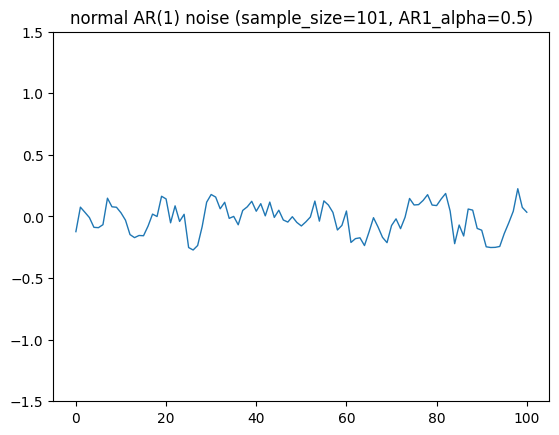

Laplace AR(1)


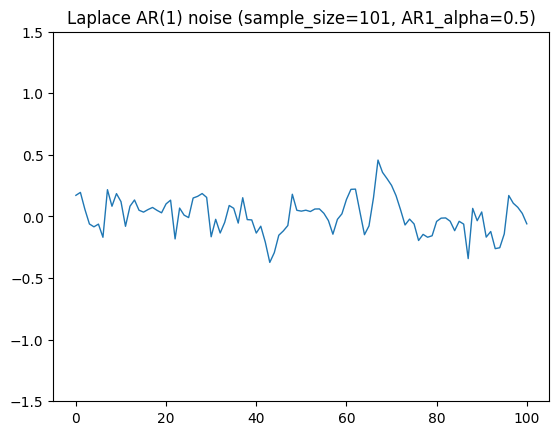

logistic AR(1)


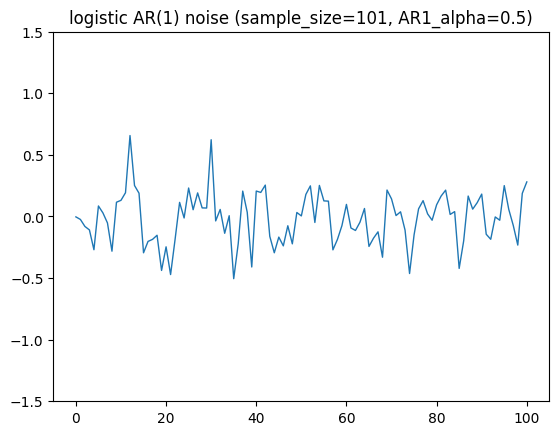

Cauchy AR(1)


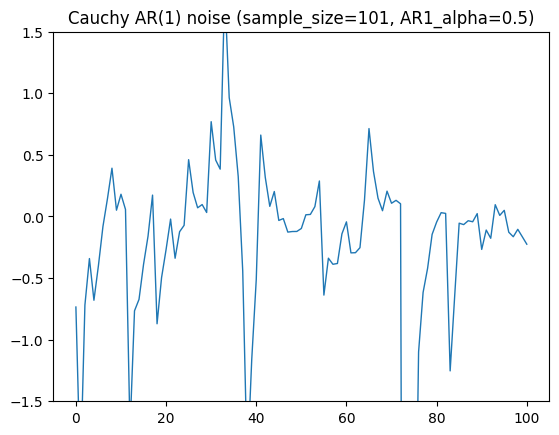

Student(2) AR(1)


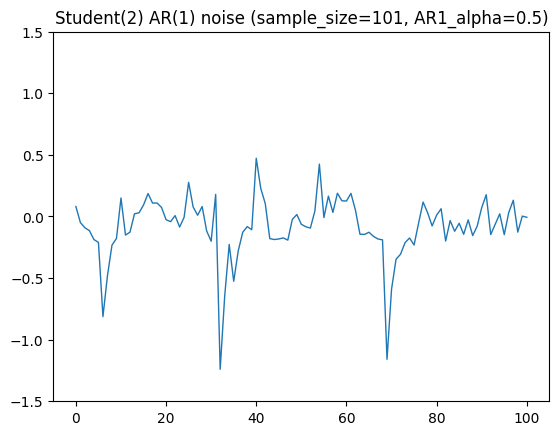

Student(3) AR(1)


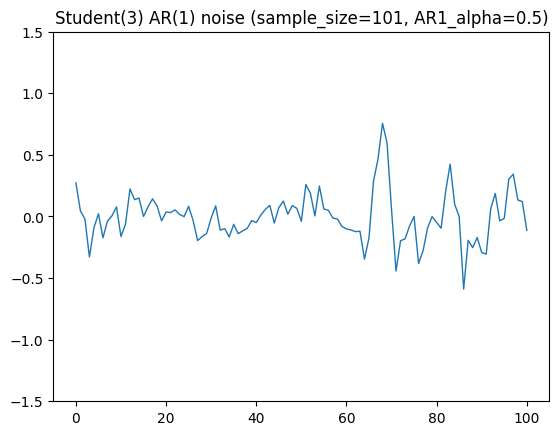

Student(4) AR(1)


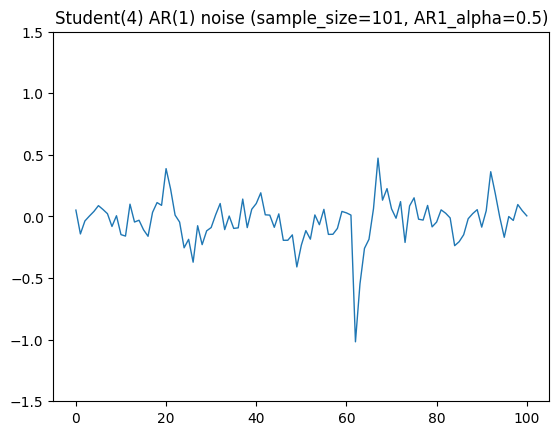

Tukey AR(1)


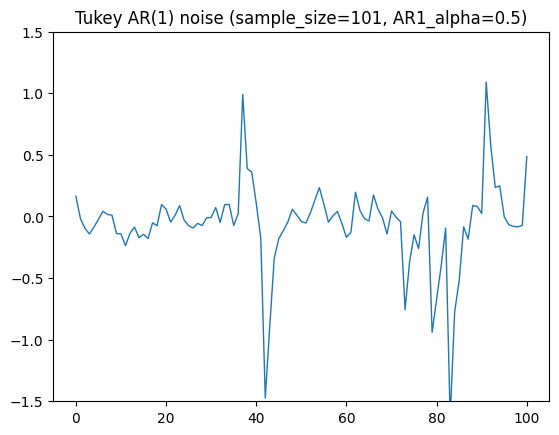

In [27]:
import scipy

save_flag = False

noise_loc = 0.0
noise_scale = 0.1

sample_count = 100

bins_array = np.linspace(-7.0 * noise_scale, 7.0 * noise_scale, 20)

noises = {
        'normal white': np.random.normal  (      loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
       'Laplace white': np.random.laplace (      loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
      'logistic white': np.random.logistic(      loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
        'Cauchy white': scipy.stats.t.rvs (df=1, loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
    'Student(2) white': scipy.stats.t.rvs (df=2, loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
    'Student(3) white': scipy.stats.t.rvs (df=3, loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
    'Student(4) white': scipy.stats.t.rvs (df=4, loc=noise_loc, scale=noise_scale, size=(sample_count, sample_size)),
         'Tukey white': random_contaminated_normal(
        loc           = noise_loc,
        main_scale    = noise_scale,
        outlier_scale = 10 * noise_scale,
        outlier_proba = 0.1,
        size          = (sample_count, sample_size)
    )
}

for key, noise in noises.items():
    print(key)
    plt.hist(noise[0], bins=bins_array)
    plt.title(f'{key} noise ({sample_size=})')
    if save_flag:
        plt.savefig(f'data/noises/{key} noise hist.png', dpi=500)
    plt.show()

AR1_alpha = 0.5

for key in list(noises.keys()):

    new_key = f'{key.split()[0]} AR(1)'
    
    noises[new_key] = np.zeros((sample_count, sample_size))
    noises[new_key][:, 0] = noises[key][:, 0]

    for i in range(1, sample_size):
        noises[new_key][:, i] = AR1_alpha * noises[new_key][:, i - 1] + noises[key][:, i]

    print(new_key)
    plt.ylim(-15 * noise_scale, 15 * noise_scale)
    plt.plot(np.arange(sample_size), noises[new_key][0], linewidth=1.0)
    plt.title(f'{new_key} noise ({sample_size=}, {AR1_alpha=})')
    if save_flag:
        plt.savefig(f'data/noises/{new_key} noise.png', dpi=500)
    plt.show()


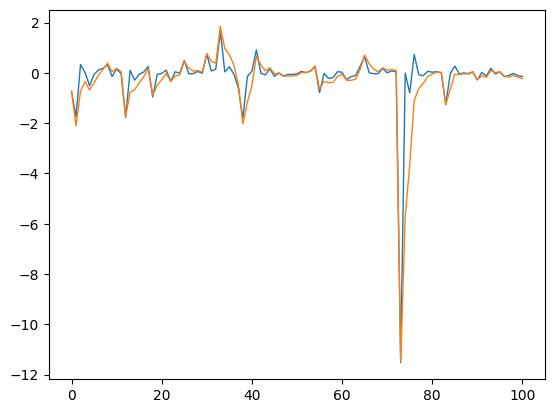

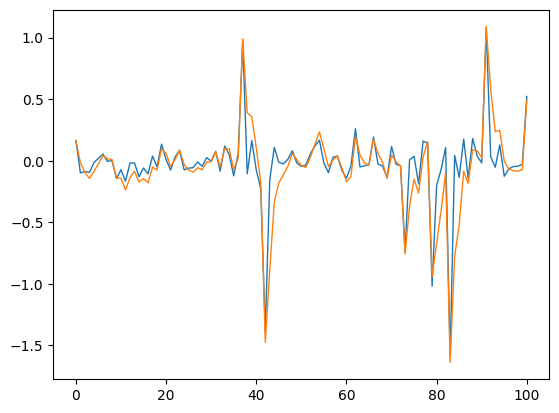

In [28]:
plt.plot(np.arange(sample_size), noises['Cauchy white'][0], linewidth=1.0)
plt.plot(np.arange(sample_size), noises['Cauchy AR(1)'][0], linewidth=1.0)
plt.show()

plt.plot(np.arange(sample_size), noises['Tukey white'][0], linewidth=1.0)
plt.plot(np.arange(sample_size), noises['Tukey AR(1)'][0], linewidth=1.0)
plt.show()

In [34]:
import djsr

for key, noise in noises.items():
    print(f'{key:<16}: {djsr.DJSR_test(noise[0])}')

normal white    : TSP + linear trend
Laplace white   : TSP + linear trend
logistic white  : TSP + linear trend
Cauchy white    : TSP + linear trend
Student(2) white: TSP + linear trend
Student(3) white: TSP + linear trend
Student(4) white: TSP + linear trend
Tukey white     : TSP + linear trend
normal AR(1)    : TSP + linear trend
Laplace AR(1)   : TSP + linear trend
logistic AR(1)  : TSP + linear trend
Cauchy AR(1)    : TSP + linear trend
Student(2) AR(1): TSP + linear trend
Student(3) AR(1): TSP + linear trend
Student(4) AR(1): TSP + linear trend
Tukey AR(1)     : TSP + linear trend


## Модель линейной регрессии с разными функциями потерь

In [35]:
import linreg

model_factories = {
    'OLS'  : linreg.OLSModelFactory(),
    'LAD'  : linreg.LADModelFactory(),
    'Log'  : linreg.LogModelFactory(),
    'Huber': linreg.HuberModelFactory(),
    'Tukey': linreg.TukeyModelFactory()
}

## Обучение

In [36]:
model_params = {
    (loss_key, noise_key): np.array(
        [
            model_factories[loss_key](X, Y + noise).params
                for noise in noises[noise_key]
        ]
    )
        for loss_key in model_factories.keys()
            for noise_key in noises.keys()
}

C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number

## Вывод результатов

In [37]:
list(noises)[:len(noises)//2]

['normal white',
 'Laplace white',
 'logistic white',
 'Cauchy white',
 'Student(2) white',
 'Student(3) white',
 'Student(4) white',
 'Tukey white']

In [38]:
def short_exp_form(x):
    man_str, exp_str = f'{x:.0e}'.split('e')
    return f'{man_str}e{int(exp_str)}'

noise_to_latex = {
    'normal'    : '$\\normallaw$',
    'Laplace'   : '$\\Laplacelaw$',
    'logistic'  : '$\\logisticlaw$',
    'Cauchy'    : '$\\Studentlaw_1$',
    'Student(2)': '$\\Studentlaw_2$',
    'Student(3)': '$\\Studentlaw_3$',
    'Student(4)': '$\\Studentlaw_4$',
    'Tukey'     : '$\\Tukeylaw$'
}

exact_params = np.array([w0_exact, w1_exact])

print(f'exact: coef = [{w0_exact:.3f} {w1_exact:.3f}]\n')

print('\\begin{center}')
print('\t\\begin{tabular}{|c|c||ccc|ccc||ccc|ccc|}')
print('\t\t\\hline')
print('\t\t\\multirow{2}{*}{noise} & \\multirow{2}{*}{loss} &')
print('\t\t\\multicolumn{6}{c||}{WN} & \\multicolumn{6}{c|}{AR(1)} \\\\')
print('\t\t\\cline{3-14}')
print('\t\t&')
print('\t\t& $\\widehat w_0$ & $\\widehat\\sigma(\\widehat w_0)$ & $\\delta(\\widehat w_0)$')
print('\t\t& $\\widehat w_1$ & $\\widehat\\sigma(\\widehat w_1)$ & $\\delta(\\widehat w_1)$')
print('\t\t& $\\widehat w_0$ & $\\widehat\\sigma(\\widehat w_0)$ & $\\delta(\\widehat w_0)$')
print('\t\t& $\\widehat w_1$ & $\\widehat\\sigma(\\widehat w_1)$ & $\\delta(\\widehat w_1)$ \\\\')

#with np.printoptions(precision=3):
#    for model_key, model in models.items():
#        print(f'({model_key[0]:5}, {model_key[1]:16}): coef = {model.params}, stderr = {model.bse}')

for noise_key in list(noises)[:len(noises)//2]:
    print('\t\t\\hline')
    print(f'\t\t\\multirow{{4}}{{*}}{{{noise_to_latex[noise_key.split()[0]]}}}')
    for loss_key in model_factories.keys():
        params_WN = model_params[(loss_key, noise_key)]
        params_AR = model_params[(loss_key, f'{noise_key.split()[0]} AR(1)')]
        means_WN  = params_WN.mean(axis=0)
        means_AR  = params_AR.mean(axis=0)
        stds_WN   = params_WN.std(axis=0)
        stds_AR   = params_AR.std(axis=0)
        delta_WN  = np.abs(means_WN - exact_params) / exact_params
        delta_AR  = np.abs(means_AR - exact_params) / exact_params
        print(
            f'\t\t& {loss_key:5} ' +
            f'& {means_WN[0]:.3f} & {stds_WN[0]:.3f} & {short_exp_form(delta_WN[0])} ' +
            f'& {means_WN[1]:.3f} & {stds_WN[1]:.3f} & {short_exp_form(delta_WN[1])} ' +
            f'& {means_AR[0]:.3f} & {stds_AR[0]:.3f} & {short_exp_form(delta_AR[0])} ' +
            f'& {means_AR[1]:.3f} & {stds_AR[1]:.3f} & {short_exp_form(delta_AR[1])} \\\\'
        )

print('\t\t\\hline')
print('\t\\end{tabular}')
print('\\end{center}')

exact: coef = [3.000 2.000]

\begin{center}
	\begin{tabular}{|c|c||ccc|ccc||ccc|ccc|}
		\hline
		\multirow{2}{*}{noise} & \multirow{2}{*}{loss} &
		\multicolumn{6}{c||}{WN} & \multicolumn{6}{c|}{AR(1)} \\
		\cline{3-14}
		&
		& $\widehat w_0$ & $\widehat\sigma(\widehat w_0)$ & $\delta(\widehat w_0)$
		& $\widehat w_1$ & $\widehat\sigma(\widehat w_1)$ & $\delta(\widehat w_1)$
		& $\widehat w_0$ & $\widehat\sigma(\widehat w_0)$ & $\delta(\widehat w_0)$
		& $\widehat w_1$ & $\widehat\sigma(\widehat w_1)$ & $\delta(\widehat w_1)$ \\
		\hline
		\multirow{4}{*}{$\normallaw$}
		& OLS   & 3.015 & 0.307 & 5e-3 & 1.998 & 0.029 & 8e-4 & 3.026 & 0.606 & 9e-3 & 1.997 & 0.058 & 1e-3 \\
		& LAD   & 3.007 & 0.449 & 2e-3 & 1.999 & 0.043 & 4e-4 & 3.070 & 0.693 & 2e-2 & 1.993 & 0.066 & 3e-3 \\
		& Log   & 3.017 & 0.324 & 6e-3 & 1.998 & 0.031 & 8e-4 & 3.027 & 0.613 & 9e-3 & 1.997 & 0.059 & 1e-3 \\
		& Huber & 3.018 & 0.341 & 6e-3 & 1.998 & 0.033 & 9e-4 & 3.027 & 0.621 & 9e-3 & 1.997 & 0.060 & 1e-3 \\
		& 


==== ==== ==== ====

normal white
OLS  : RMSE = 0.001, MAE = 0.001
LAD  : RMSE = 0.001, MAE = 0.001
Log  : RMSE = 0.001, MAE = 0.001
Huber: RMSE = 0.001, MAE = 0.001
Tukey: RMSE = 0.001, MAE = 0.001


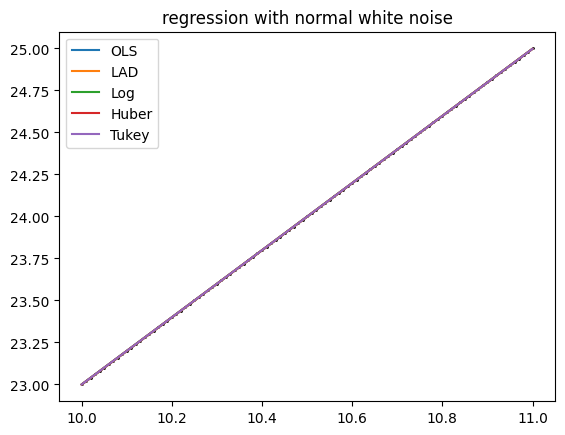


==== ==== ==== ====

Laplace white
OLS  : RMSE = 0.001, MAE = 0.001
LAD  : RMSE = 0.000, MAE = 0.000
Log  : RMSE = 0.000, MAE = 0.000
Huber: RMSE = 0.000, MAE = 0.000
Tukey: RMSE = 0.000, MAE = 0.000


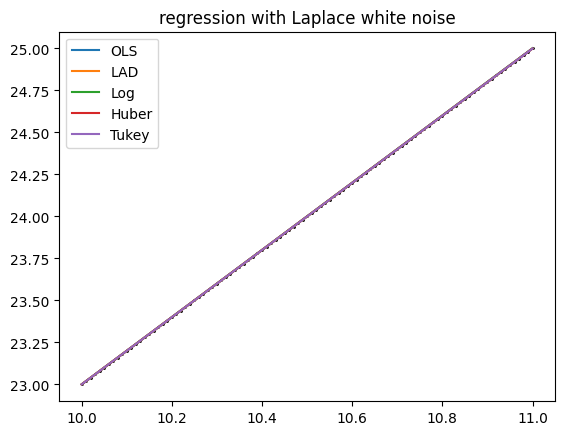


==== ==== ==== ====

logistic white
OLS  : RMSE = 0.001, MAE = 0.001
LAD  : RMSE = 0.003, MAE = 0.003
Log  : RMSE = 0.001, MAE = 0.001
Huber: RMSE = 0.001, MAE = 0.001
Tukey: RMSE = 0.001, MAE = 0.001


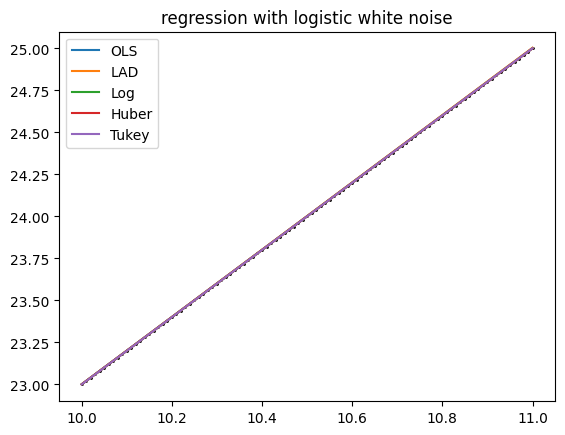


==== ==== ==== ====

Cauchy white
OLS  : RMSE = 0.056, MAE = 0.048
LAD  : RMSE = 0.003, MAE = 0.003
Log  : RMSE = 0.007, MAE = 0.007
Huber: RMSE = 0.006, MAE = 0.005
Tukey: RMSE = 0.004, MAE = 0.004


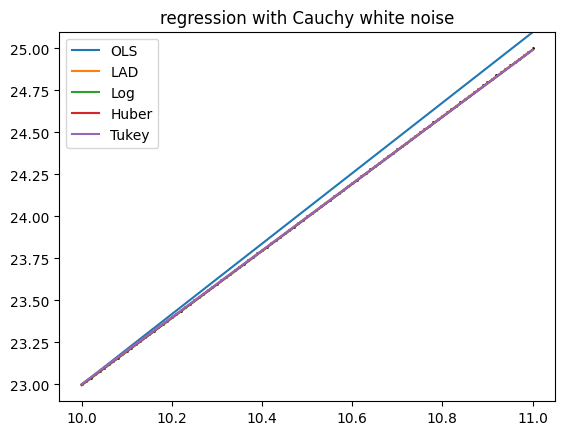


==== ==== ==== ====

Student(2) white
OLS  : RMSE = 0.003, MAE = 0.003
LAD  : RMSE = 0.001, MAE = 0.001
Log  : RMSE = 0.002, MAE = 0.001
Huber: RMSE = 0.002, MAE = 0.002
Tukey: RMSE = 0.002, MAE = 0.002


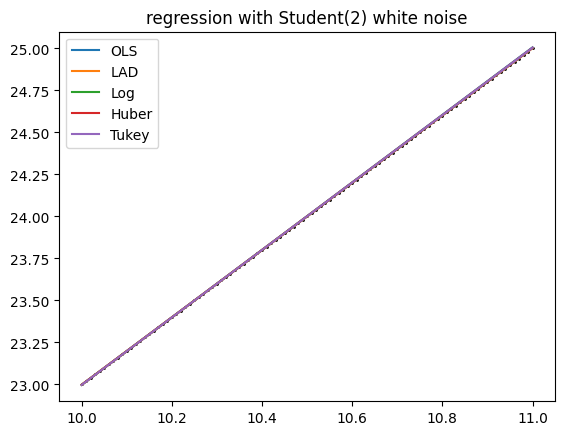


==== ==== ==== ====

Student(3) white
OLS  : RMSE = 0.004, MAE = 0.004
LAD  : RMSE = 0.003, MAE = 0.003
Log  : RMSE = 0.004, MAE = 0.004
Huber: RMSE = 0.004, MAE = 0.004
Tukey: RMSE = 0.004, MAE = 0.004


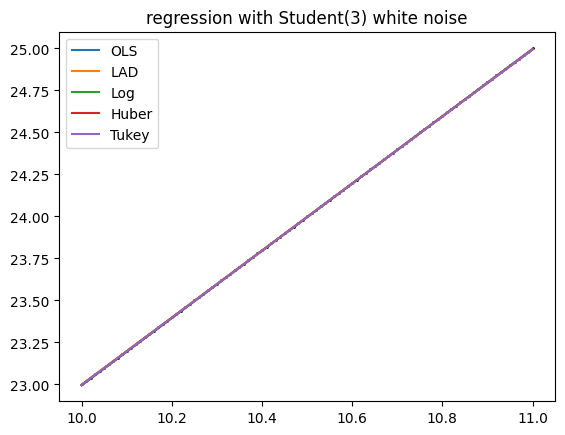


==== ==== ==== ====

Student(4) white
OLS  : RMSE = 0.002, MAE = 0.002
LAD  : RMSE = 0.002, MAE = 0.002
Log  : RMSE = 0.002, MAE = 0.002
Huber: RMSE = 0.002, MAE = 0.002
Tukey: RMSE = 0.002, MAE = 0.002


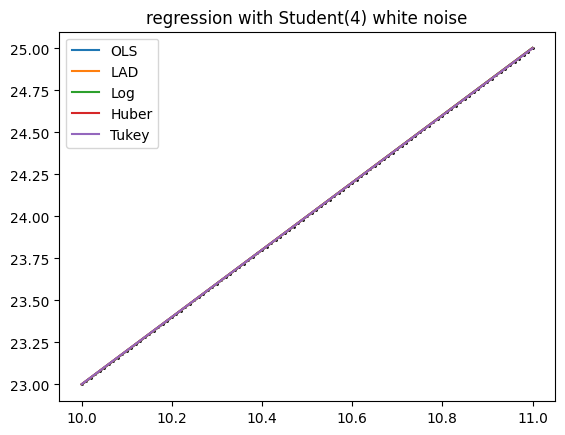


==== ==== ==== ====

Tukey white
OLS  : RMSE = 0.005, MAE = 0.004
LAD  : RMSE = 0.002, MAE = 0.002
Log  : RMSE = 0.001, MAE = 0.001
Huber: RMSE = 0.001, MAE = 0.001
Tukey: RMSE = 0.001, MAE = 0.001


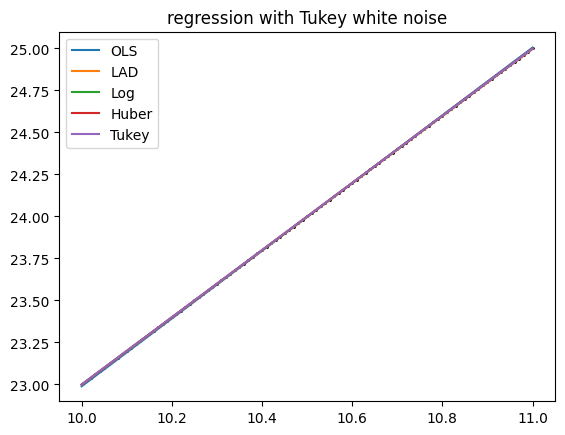


==== ==== ==== ====

normal AR(1)
OLS  : RMSE = 0.002, MAE = 0.001
LAD  : RMSE = 0.002, MAE = 0.002
Log  : RMSE = 0.001, MAE = 0.001
Huber: RMSE = 0.001, MAE = 0.001
Tukey: RMSE = 0.001, MAE = 0.001


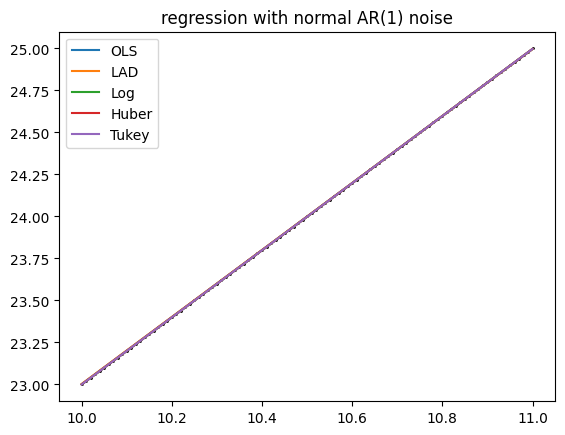


==== ==== ==== ====

Laplace AR(1)
OLS  : RMSE = 0.002, MAE = 0.002
LAD  : RMSE = 0.002, MAE = 0.002
Log  : RMSE = 0.001, MAE = 0.001
Huber: RMSE = 0.001, MAE = 0.001
Tukey: RMSE = 0.001, MAE = 0.001


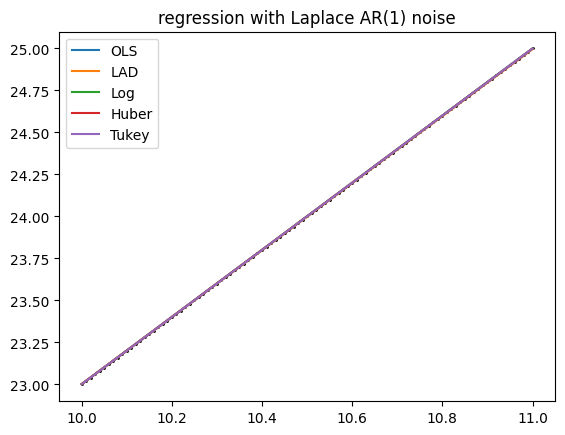


==== ==== ==== ====

logistic AR(1)
OLS  : RMSE = 0.003, MAE = 0.003
LAD  : RMSE = 0.005, MAE = 0.004
Log  : RMSE = 0.003, MAE = 0.003
Huber: RMSE = 0.003, MAE = 0.003
Tukey: RMSE = 0.003, MAE = 0.003


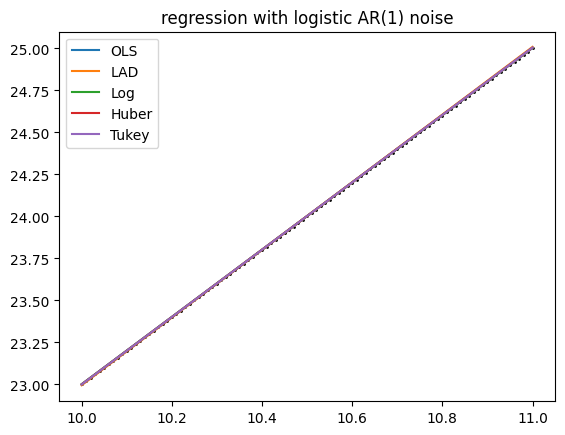


==== ==== ==== ====

Cauchy AR(1)
OLS  : RMSE = 0.110, MAE = 0.094
LAD  : RMSE = 0.020, MAE = 0.020
Log  : RMSE = 0.025, MAE = 0.025
Huber: RMSE = 0.023, MAE = 0.023
Tukey: RMSE = 0.023, MAE = 0.023


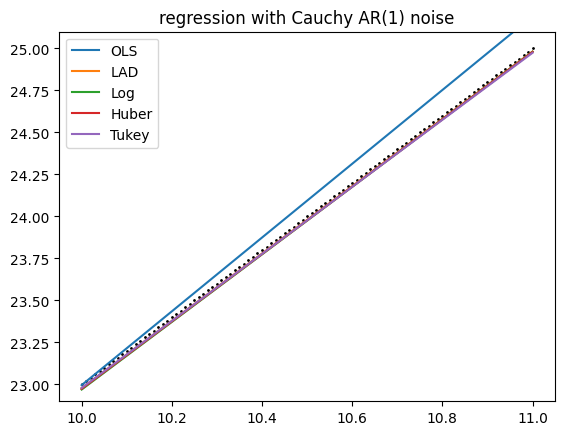


==== ==== ==== ====

Student(2) AR(1)
OLS  : RMSE = 0.007, MAE = 0.006
LAD  : RMSE = 0.006, MAE = 0.005
Log  : RMSE = 0.003, MAE = 0.002
Huber: RMSE = 0.003, MAE = 0.003
Tukey: RMSE = 0.004, MAE = 0.003


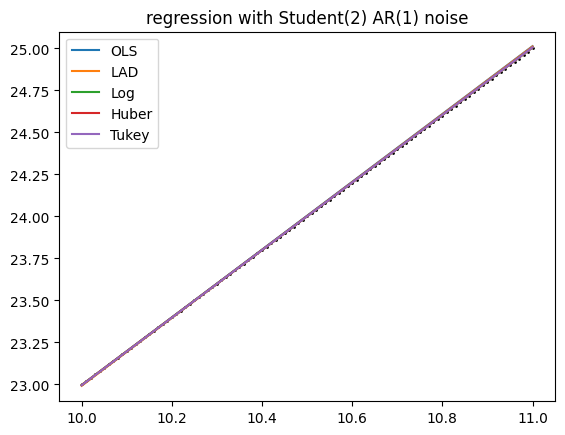


==== ==== ==== ====

Student(3) AR(1)
OLS  : RMSE = 0.008, MAE = 0.008
LAD  : RMSE = 0.009, MAE = 0.008
Log  : RMSE = 0.008, MAE = 0.008
Huber: RMSE = 0.008, MAE = 0.008
Tukey: RMSE = 0.009, MAE = 0.009


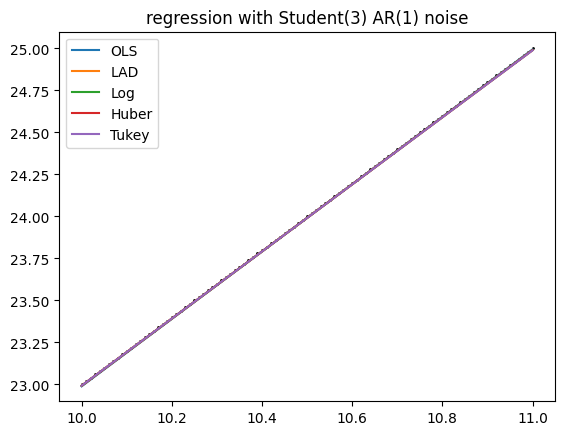


==== ==== ==== ====

Student(4) AR(1)
OLS  : RMSE = 0.004, MAE = 0.003
LAD  : RMSE = 0.003, MAE = 0.002
Log  : RMSE = 0.003, MAE = 0.003
Huber: RMSE = 0.003, MAE = 0.003
Tukey: RMSE = 0.003, MAE = 0.003


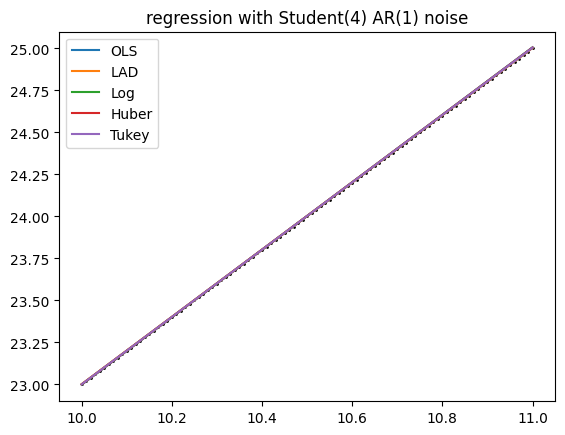


==== ==== ==== ====

Tukey AR(1)
OLS  : RMSE = 0.010, MAE = 0.009
LAD  : RMSE = 0.005, MAE = 0.004
Log  : RMSE = 0.005, MAE = 0.004
Huber: RMSE = 0.004, MAE = 0.004
Tukey: RMSE = 0.003, MAE = 0.003


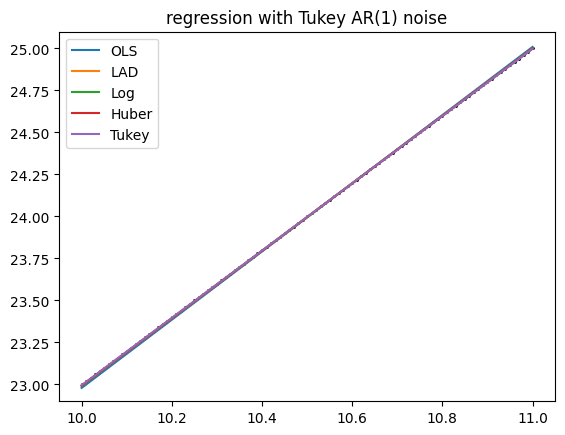

In [41]:
from statsmodels.api import add_constant
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error

save_flag = False

for noise_key in noises.keys():

    outputs = {
        loss_key: add_constant(X) @ model_params[(loss_key, noise_key)].mean(axis=0).T
            for loss_key in model_factories.keys()
    }

    print('\n==== ==== ==== ====\n')
    print(noise_key)
    
    for loss_key in model_factories.keys():
        rmse = root_mean_squared_error(Y, outputs[loss_key])
        mae = mean_absolute_error(Y, outputs[loss_key])
        print(f'{loss_key:5}: RMSE = {rmse:.3f}, MAE = {mae:.3f}')
    
    #for loss_key in trainers.keys():
    #    plt.plot(np.arange(100), loss_histories[(loss_key, noise_key)], label=loss_key)

    #plt.ylim(-0.1, 3.1)
    #plt.legend()
    #plt.xlabel('optimization step')
    #plt.ylabel('loss value')
    #plt.title(  f'loss history with {noise_key} noise')
    #if save_flag:
    #    plt.savefig(f'data/loss history/{noise_key} noise.png', dpi=500)
    #plt.show()

    plt.scatter(
        X,
        Y,#_noised[noise_key],
        color='black',
        #linewidth=0.5,
        s=1.0,
        #alpha=0.5
    )
    
    for loss_key in model_factories.keys():
        plt.plot(X, outputs[loss_key], label=loss_key)

    plt.ylim(22.9, 25.1)
    plt.legend()
    plt.title(  f'regression with {noise_key} noise')
    if save_flag:
        plt.savefig(f'data/regression/{noise_key} noise.png', dpi=500)
    plt.show()


## Исследование на асимптотические свойства

In [42]:
def random_subsample_index(array_len, ratio):
    
    true_count = int(array_len * ratio)
    
    result = np.zeros(array_len)
    result[:true_count] = np.ones(true_count)
    
    np.random.shuffle(result)
    
    return result.astype('bool')


In [59]:
ratios = np.linspace(0.0, 1.0, 21)[1:]
ratios

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [60]:
w0_data = {
    (loss_key, noise_key): []
        for loss_key in model_factories.keys()
            for noise_key in noises.keys()
}

w1_data = {
    (loss_key, noise_key): []
        for loss_key in model_factories.keys()
            for noise_key in noises.keys()
}


for ratio in ratios:

    print(f'processing ratio = {ratio:.3f} . . .')
    
    index = random_subsample_index(sample_size, ratio)

    for loss_key in model_factories.keys():
        
        for noise_key in noises.keys():
            
            model = model_factories[loss_key](X[index], Y[index] + noises[noise_key][0, index])
            
            w0_data[(loss_key, noise_key)].append(model.params[0])
            w1_data[(loss_key, noise_key)].append(model.params[1])


processing ratio = 0.050 . . .
processing ratio = 0.100 . . .
processing ratio = 0.150 . . .
processing ratio = 0.200 . . .
processing ratio = 0.250 . . .
processing ratio = 0.300 . . .


C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


processing ratio = 0.350 . . .
processing ratio = 0.400 . . .
processing ratio = 0.450 . . .
processing ratio = 0.500 . . .
processing ratio = 0.550 . . .
processing ratio = 0.600 . . .
processing ratio = 0.650 . . .


C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


processing ratio = 0.700 . . .
processing ratio = 0.750 . . .
processing ratio = 0.800 . . .
processing ratio = 0.850 . . .
processing ratio = 0.900 . . .
processing ratio = 0.950 . . .


C:\Users\artko\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


processing ratio = 1.000 . . .



w0_data


normal white


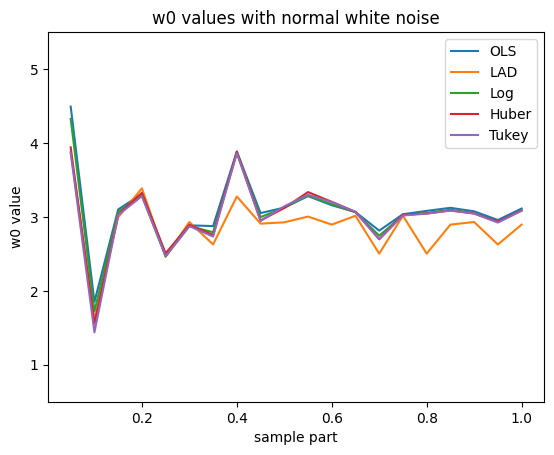


Laplace white


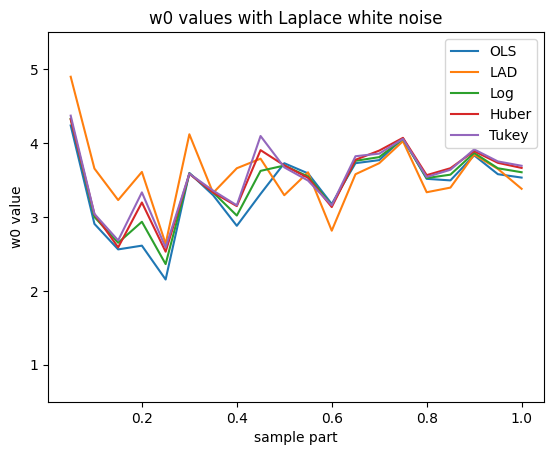


logistic white


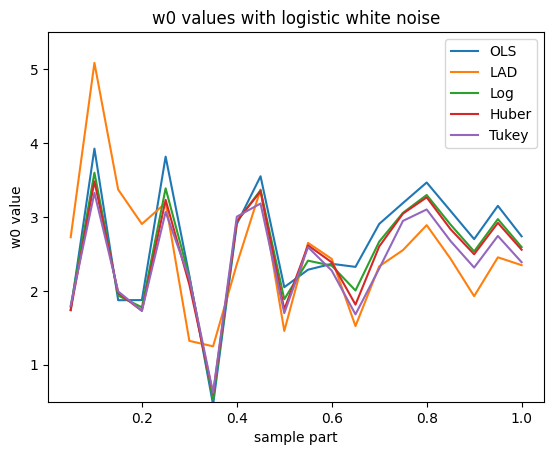


Cauchy white


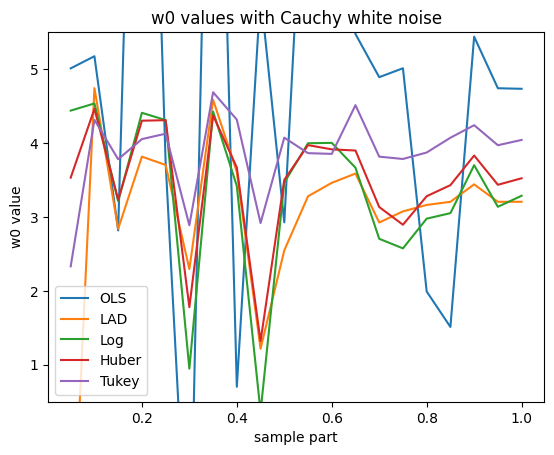


Student(2) white


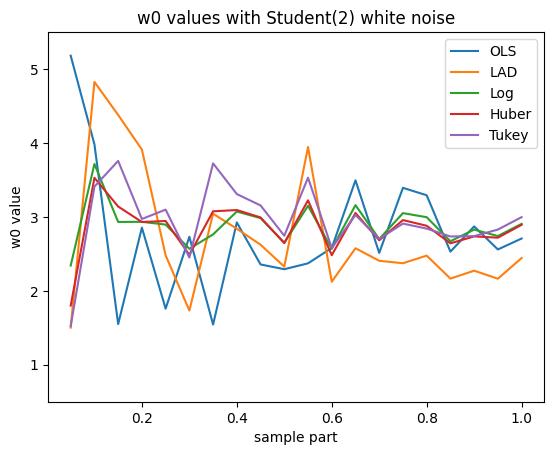


Student(3) white


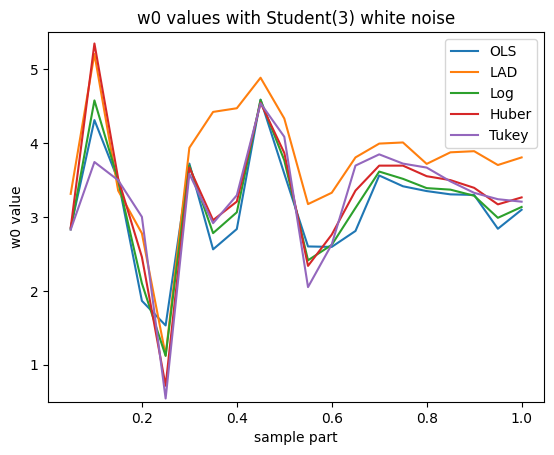


Student(4) white


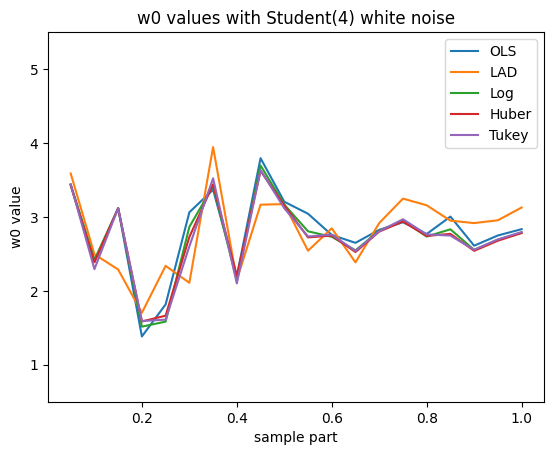


Tukey white


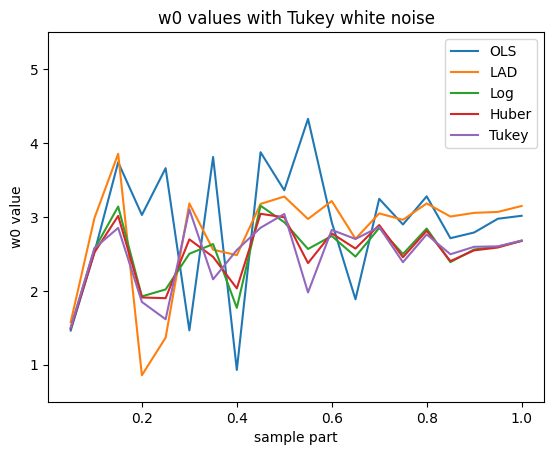


normal AR(1)


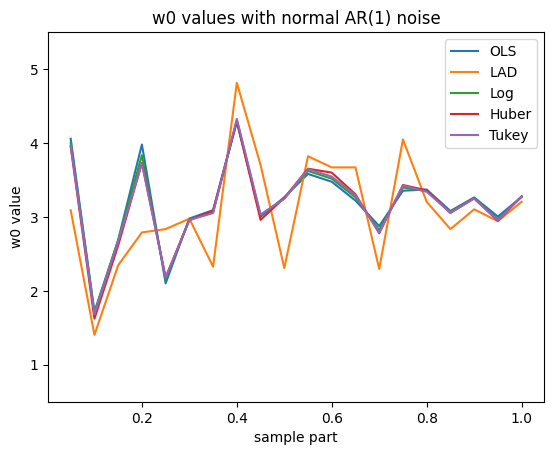


Laplace AR(1)


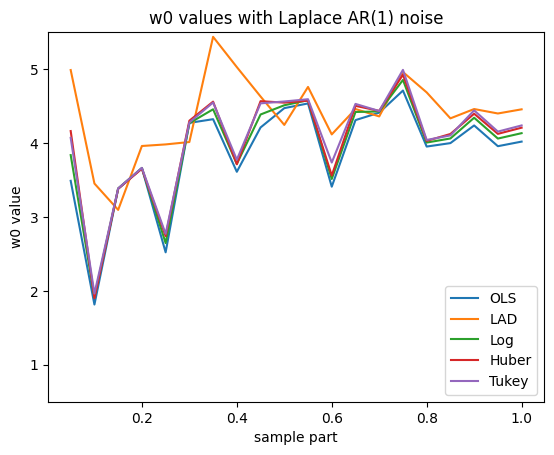


logistic AR(1)


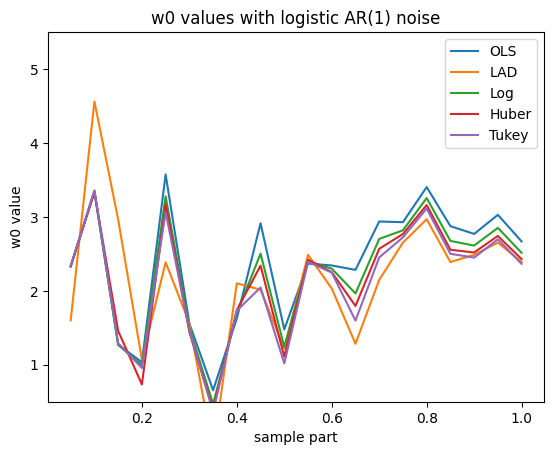


Cauchy AR(1)


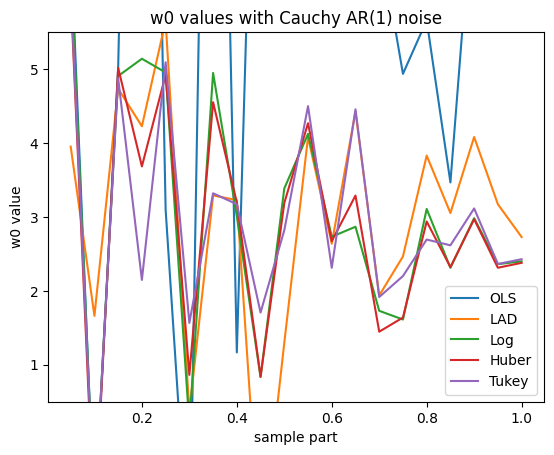


Student(2) AR(1)


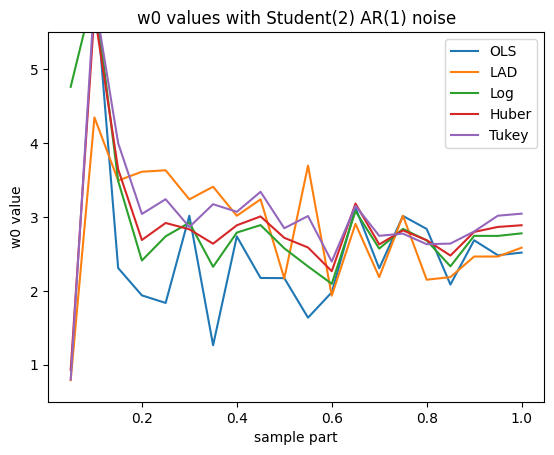


Student(3) AR(1)


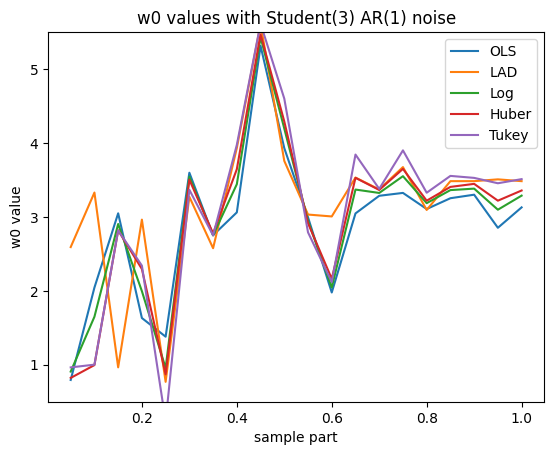


Student(4) AR(1)


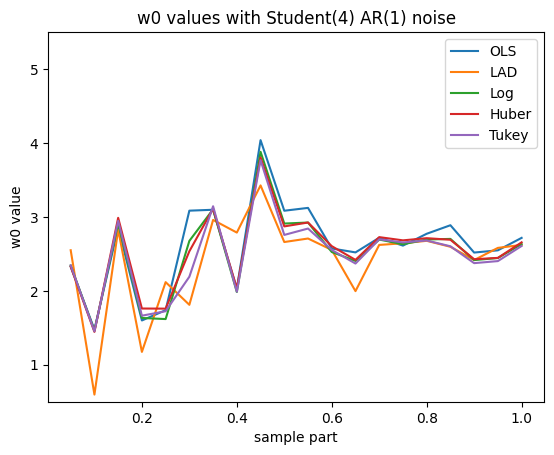


Tukey AR(1)


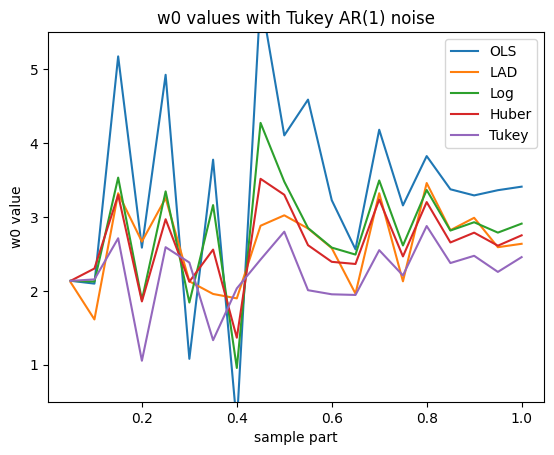


w1_data


normal white


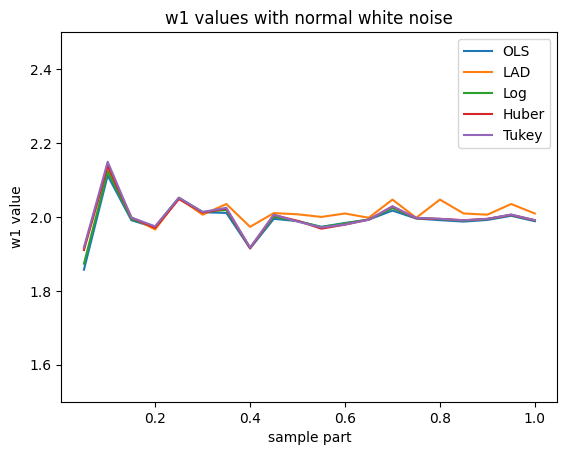


Laplace white


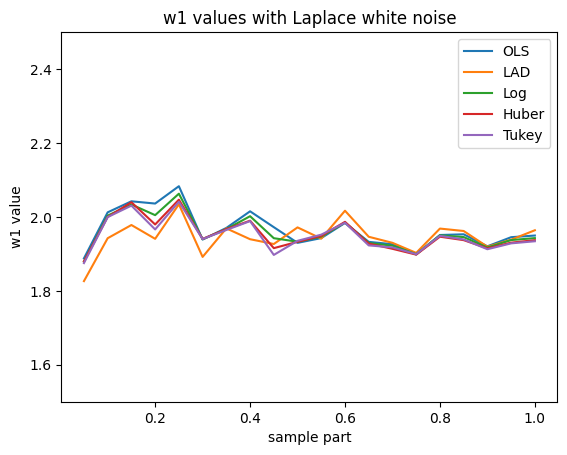


logistic white


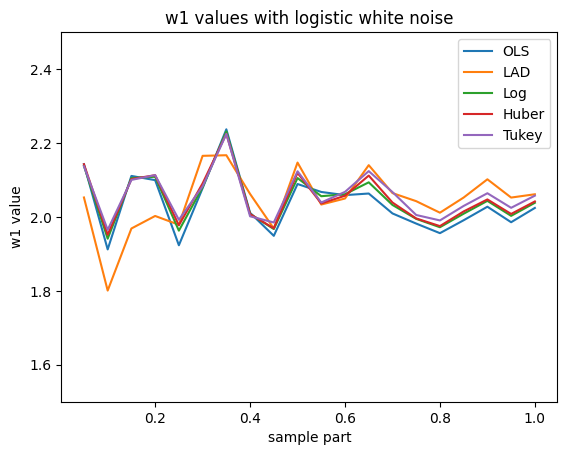


Cauchy white


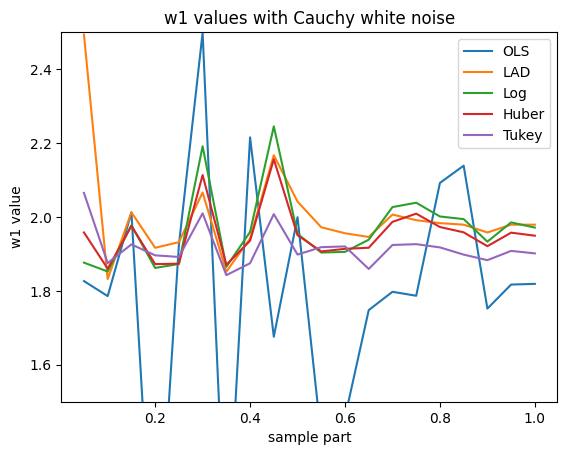


Student(2) white


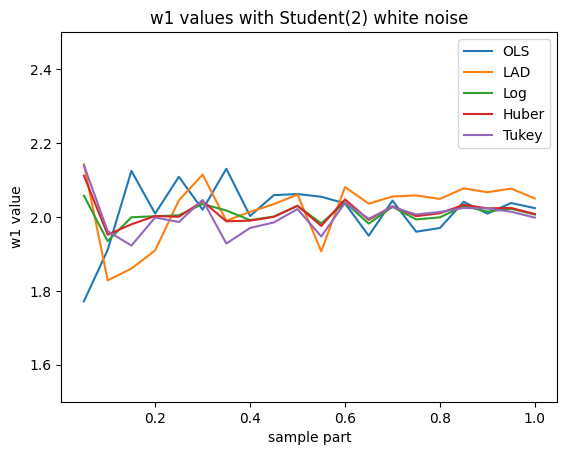


Student(3) white


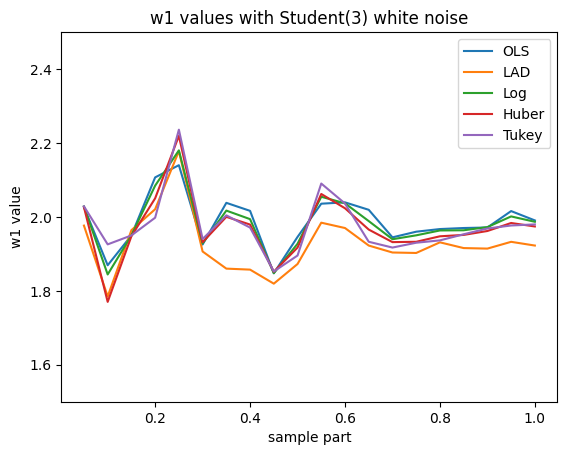


Student(4) white


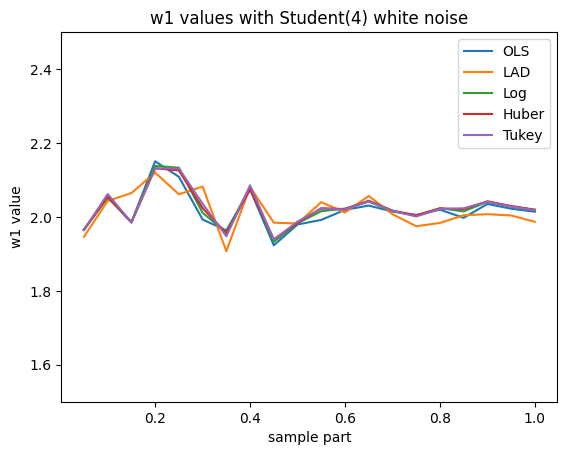


Tukey white


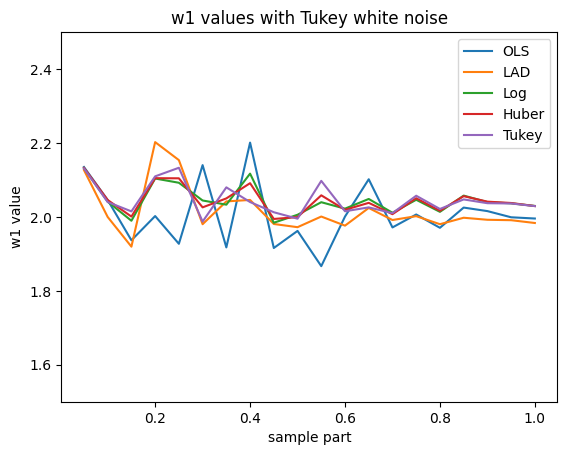


normal AR(1)


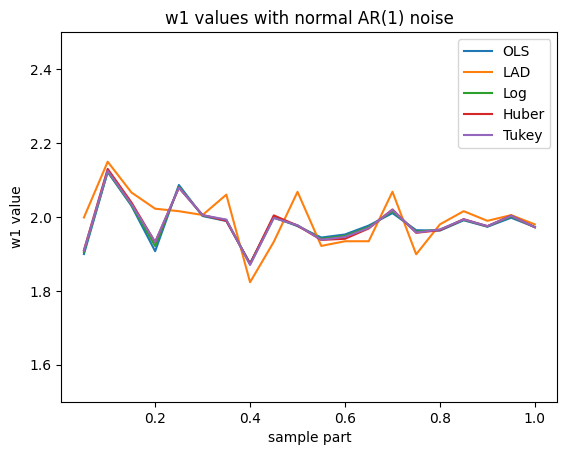


Laplace AR(1)


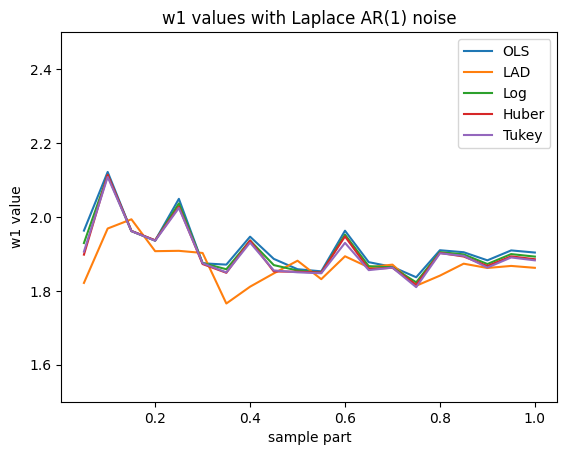


logistic AR(1)


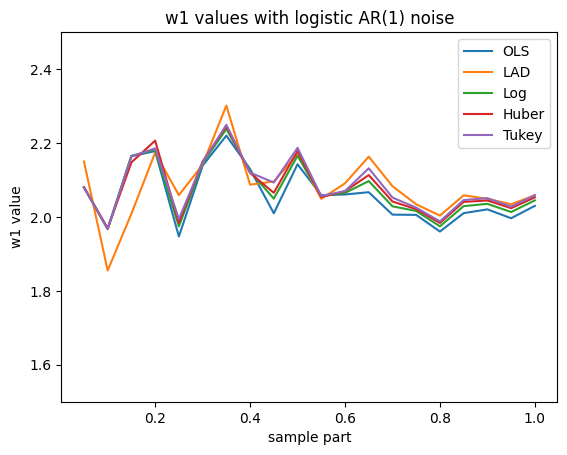


Cauchy AR(1)


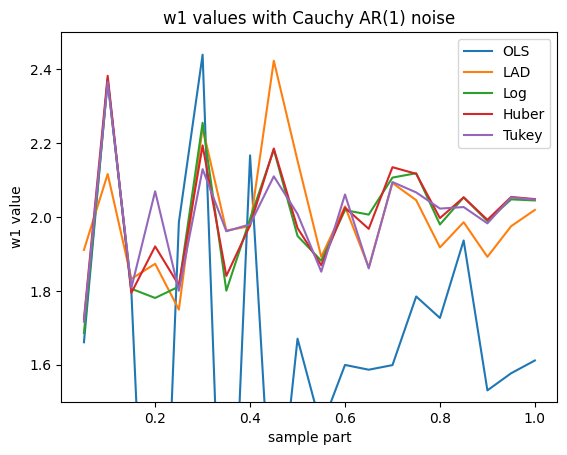


Student(2) AR(1)


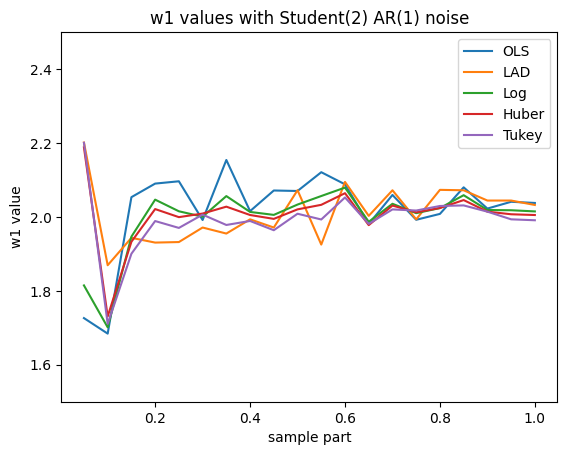


Student(3) AR(1)


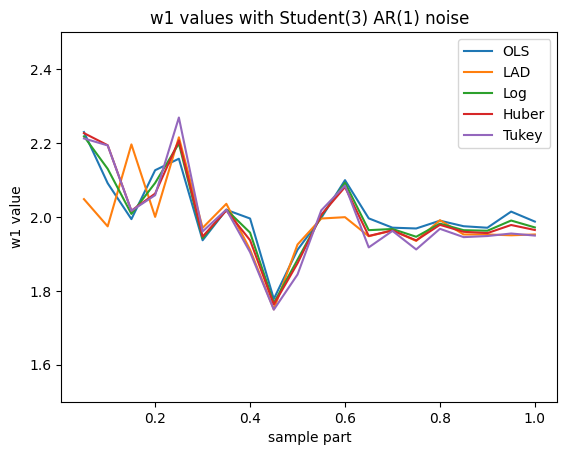


Student(4) AR(1)


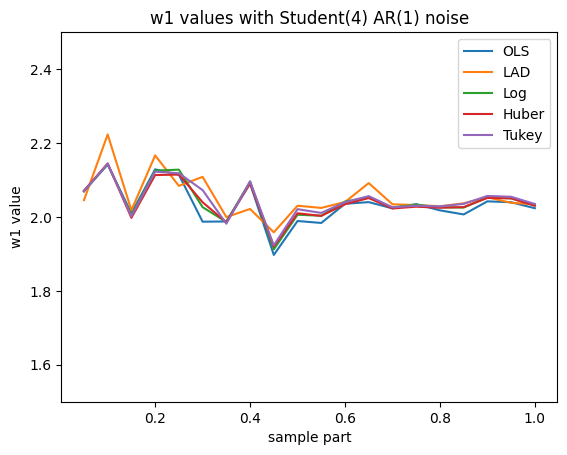


Tukey AR(1)


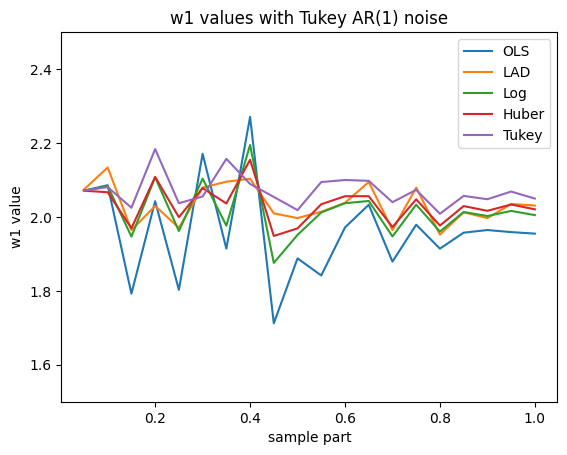

In [61]:
save_flag = False

print('\nw0_data\n')

for noise_key in noises.keys():
    print('\n' + noise_key)
    for loss_key in model_factories.keys():
        plt.plot(ratios, w0_data[(loss_key, noise_key)], label=loss_key)
    plt.ylim(w0_exact - 2.5, w0_exact + 2.5)
    plt.legend()
    plt.xlabel('sample part')
    plt.ylabel('w0 value')
    plt.title(  f'w0 values with {noise_key} noise')
    if save_flag:
        plt.savefig(f'data/w0 values/{noise_key} noise', dpi=500)
    plt.show()

print('\nw1_data\n')

for noise_key in noises.keys():
    print('\n' + noise_key)
    for loss_key in model_factories.keys():
        plt.plot(ratios, w1_data[(loss_key, noise_key)], label=loss_key)
    plt.ylim(w1_exact - 0.5, w1_exact + 0.5)
    plt.legend()
    plt.xlabel('sample part')
    plt.ylabel('w1 value')
    plt.title(  f'w1 values with {noise_key} noise')
    if save_flag:
        plt.savefig(f'data/w1 values/{noise_key} noise', dpi=500)
    plt.show()
